In [1]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
df.shape

(284807, 31)

In [3]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [4]:
# Check for missing values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:
# Check class distribution
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [6]:
# Check class distribution percentage
df['Class'].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

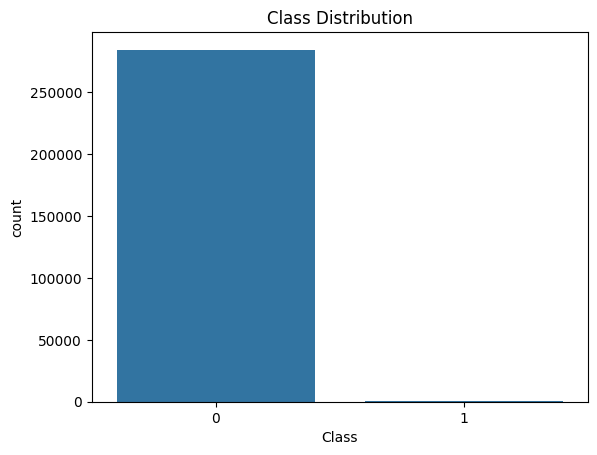

In [7]:
# Visualize class distribution
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

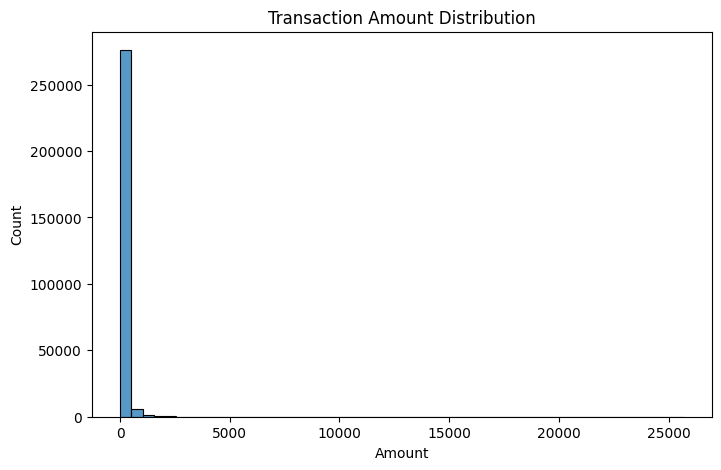

In [8]:
# Visualize transaction amount distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

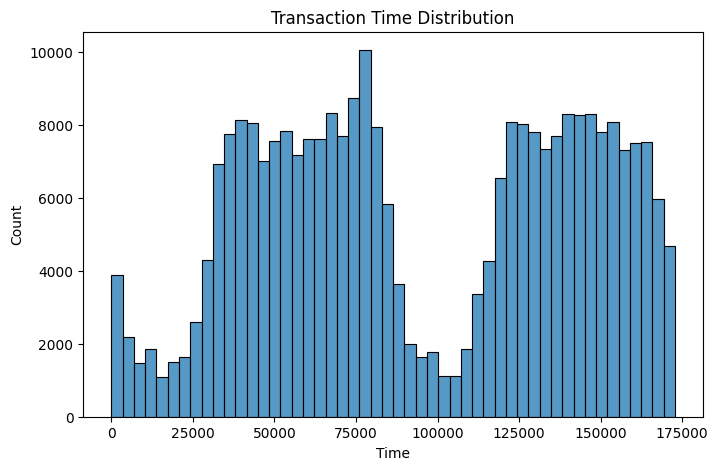

In [9]:
# Visualize transaction time distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Time'], bins=50)
plt.title("Transaction Time Distribution")
plt.show()

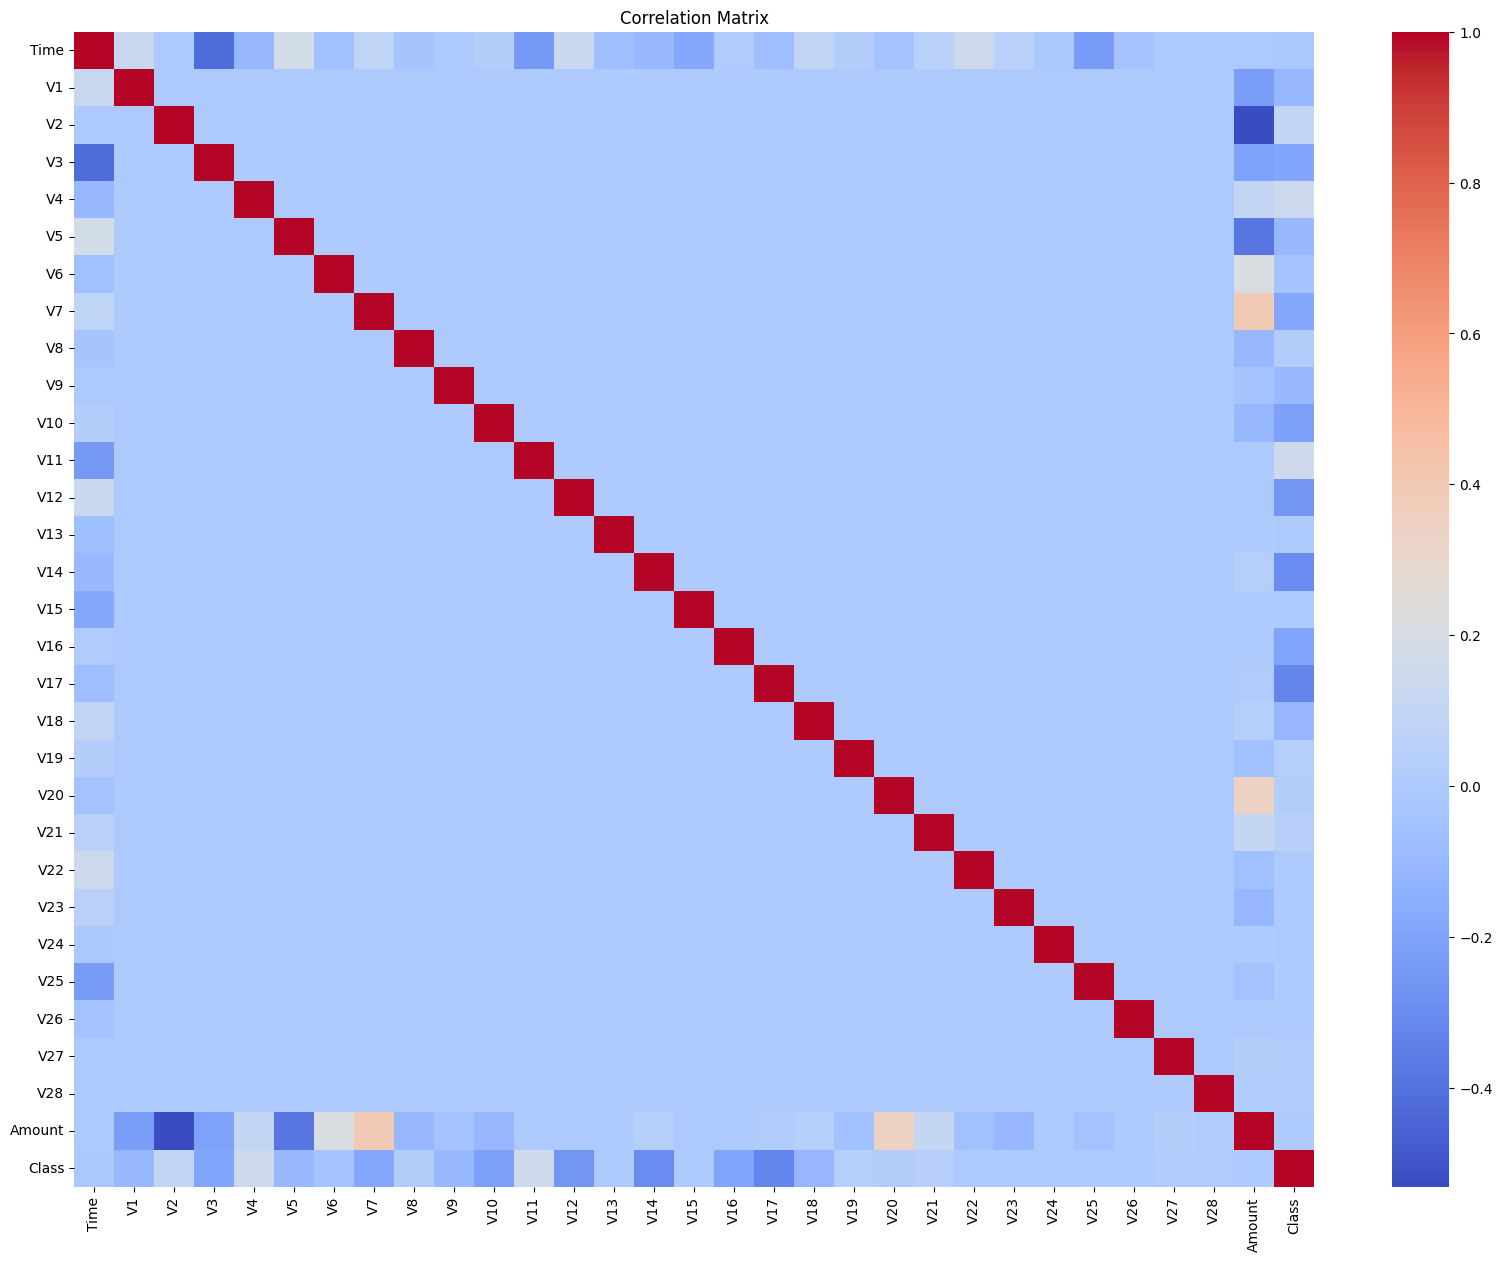

In [10]:
# Correlation matrix
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Matrix")
plt.show()

In [11]:
# Correlation with target variable
df.corr()['Class'].sort_values(ascending=False)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

In [12]:
# Separate fraud and legitimate transactions
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

fraud.describe()
legit.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,...,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.0
mean,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022,0.0
std,47484.015786,1.929814,1.636146,1.459429,1.399333,1.356952,1.329913,1.178812,1.161283,1.089372,...,0.716743,0.723668,0.621541,0.605776,0.520673,0.482241,0.399847,0.329570,250.105092,0.0
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-31.764946,-73.216718,-6.290730,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.0
25%,54230.000000,-0.917544,-0.599473,-0.884541,-0.850077,-0.689398,-0.766847,-0.551442,-0.208633,-0.640412,...,-0.228509,-0.542403,-0.161702,-0.354425,-0.317145,-0.327074,-0.070852,-0.052950,5.650000,0.0
50%,84711.000000,0.020023,0.064070,0.182158,-0.022405,-0.053457,-0.273123,0.041138,0.022041,-0.049964,...,-0.029821,0.006736,-0.011147,0.041082,0.016417,-0.052227,0.001230,0.011199,22.000000,0.0
75%,139333.000000,1.316218,0.800446,1.028372,0.737624,0.612181,0.399619,0.571019,0.326200,0.598230,...,0.185626,0.528407,0.147522,0.439869,0.350594,0.240671,0.090573,0.077962,77.050000,0.0
max,172792.000000,2.454930,18.902453,9.382558,16.875344,34.801666,73.301626,120.589494,18.709255,15.594995,...,22.614889,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,0.0


In [13]:
#Separate Features and Target
X = df.drop("Class", axis=1)
y = df["Class"]

In [14]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

In [15]:
# Scale 'Amount' and 'Time' features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[['Amount', 'Time']] = scaler.fit_transform(
    X_train[['Amount', 'Time']]
)

X_test[['Amount', 'Time']] = scaler.transform(
    X_test[['Amount', 'Time']]
)

In [16]:
# Handle class imbalance using SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

y_train_resampled.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

In [17]:
import sys
import os

sys.path.append(os.path.abspath(".."))
import pandas as pd
from src.data_preprocessing import preprocess_data

df = pd.read_csv("../data/creditcard.csv")

X_train, X_test, y_train, y_test = preprocess_data(df)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (454902, 30)
Test shape: (56962, 30)


In [18]:
import sys, os
sys.path.append(os.path.abspath(".."))

from src.data_preprocessing import preprocess_data
from src.train_model import (
    train_logistic_regression,
    train_xgboost,
    train_isolation_forest,
    evaluate_model
)

import pandas as pd

df = pd.read_csv("../data/creditcard.csv")

X_train, X_test, y_train, y_test = preprocess_data(df)

In [19]:
log_model = train_logistic_regression(X_train, y_train)
evaluate_model(log_model, X_test, y_test, "LogisticRegression")


--- LogisticRegression Evaluation ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC Score: 0.9698631105509169


In [20]:
xgb_model = train_xgboost(X_train, y_train)
evaluate_model(xgb_model, X_test, y_test, "XGBoost")

c:\Users\harip\OneDrive\Desktop\AIML Internship\Projects\Fraud-Detection-ML\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:24:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.24      0.89      0.38        98

    accuracy                           0.99     56962
   macro avg       0.62      0.94      0.69     56962
weighted avg       1.00      0.99      1.00     56962

ROC-AUC Score: 0.9780539748257209


In [21]:
iso_model = train_isolation_forest(X_train)
evaluate_model(iso_model, X_test, y_test, "IsolationForest")


--- IsolationForest Evaluation ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962



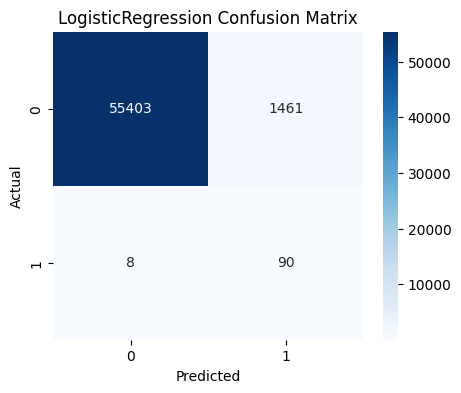

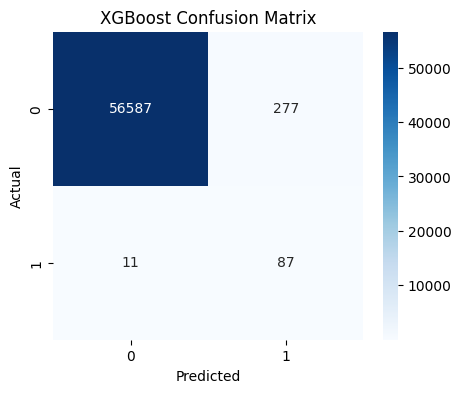

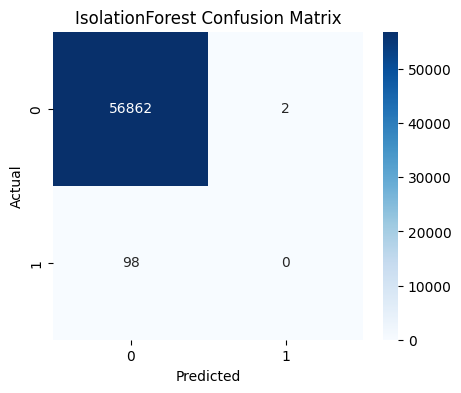

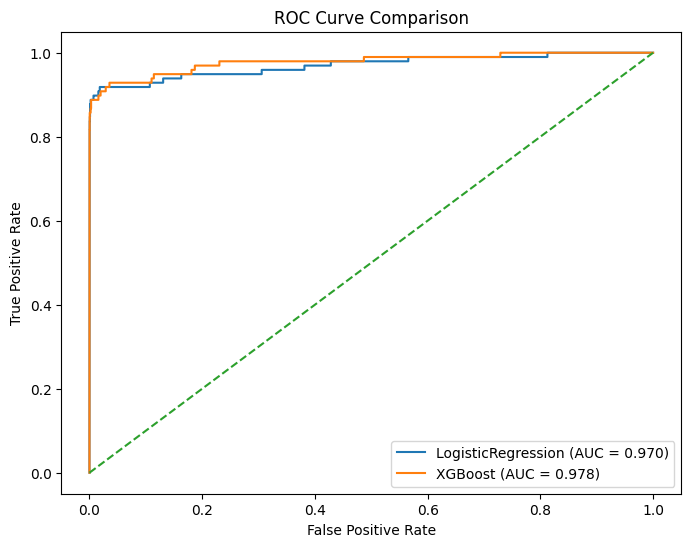

In [22]:
from src.evaluate import (
    plot_confusion_matrix,
    compare_roc_curves
)

plot_confusion_matrix(log_model, X_test, y_test, "LogisticRegression")
plot_confusion_matrix(xgb_model, X_test, y_test, "XGBoost")
plot_confusion_matrix(iso_model, X_test, y_test, "IsolationForest")

models = {
    "LogisticRegression": log_model,
    "XGBoost": xgb_model
}

compare_roc_curves(models, X_test, y_test)

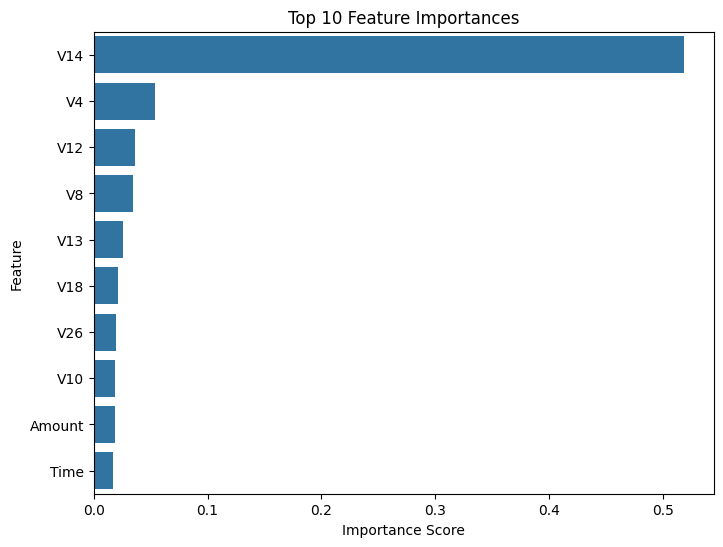

In [23]:
from src.evaluate import plot_feature_importance

feature_names = X_train.columns

plot_feature_importance(xgb_model, feature_names, top_n=10)

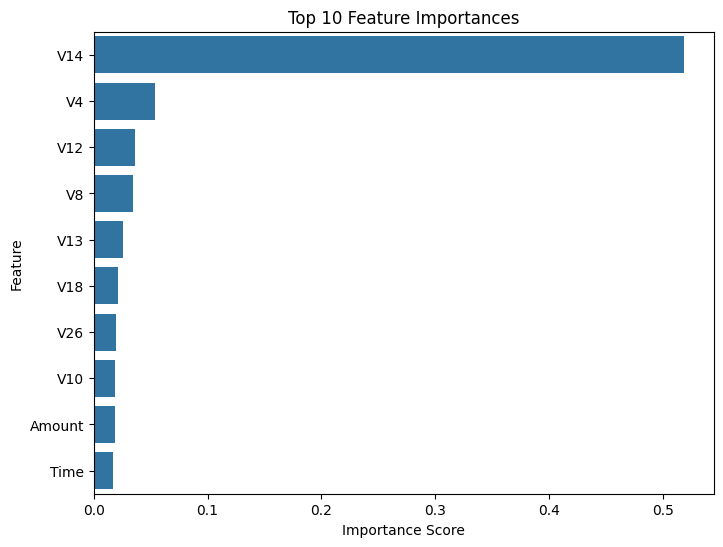

In [24]:
plot_feature_importance(
    xgb_model,
    feature_names,
    top_n=10,
    save_path="../outputs/feature_importance.png"
)

In [25]:
import joblib

joblib.dump(xgb_model, "../models/xgboost_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']